In [2]:
# Cell gọi dữ liệu
import pandas as pd 
import os
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('Đang khai báo dữ liệu')

# Dữ liệu thô ban đầu
file_path = os.path.join("..", "Data", "train.csv")

df = pd.read_csv(file_path)

print('Khai báo thành công')

Đang khai báo dữ liệu
Khai báo thành công


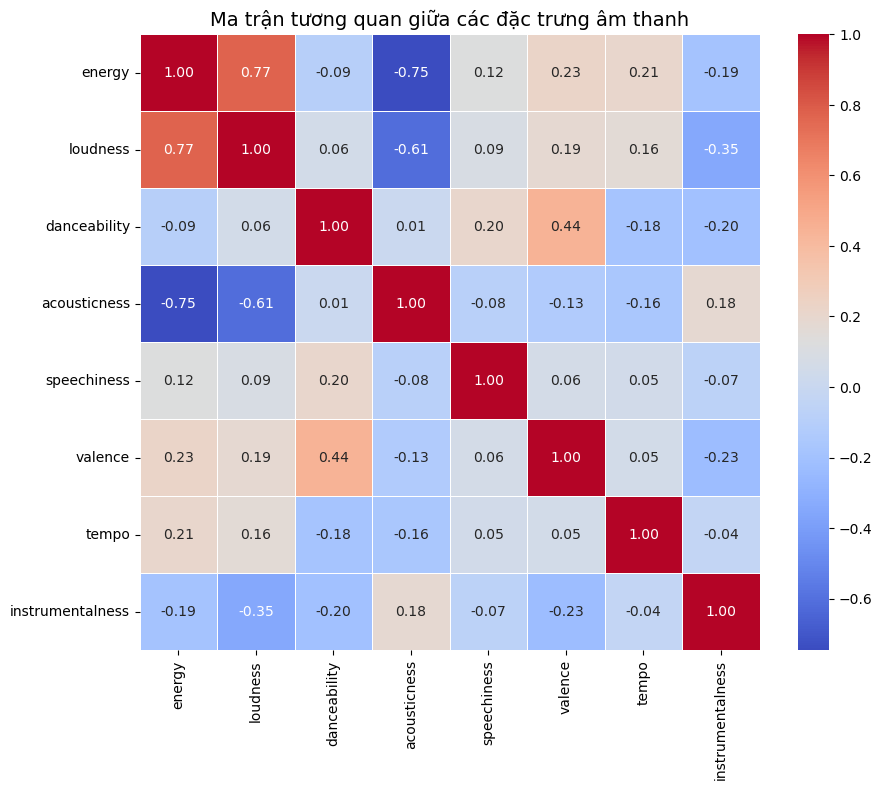

In [5]:
# ================================
# MA TRẬN TƯƠNG QUAN (CORRELATION MATRIX)
# ================================

# Chọn các feature cần phân tích
features = [
    'energy',
    'loudness',
    'danceability',
    'acousticness',
    'speechiness',
    'valence',
    'tempo',
    'instrumentalness'
]

# Tính ma trận tương quan
corr_matrix = df[features].corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,     
    cmap='coolwarm', 
    fmt='.2f',       
    linewidths=0.5
)

# Tiêu đề
plt.title("Ma trận tương quan giữa các đặc trưng âm thanh", fontsize=14)

# Hiển thị biểu đồ
plt.show()

# Chọn các feature này vì đây là những đặc trưng âm thanh
# phản ánh rõ phong cách và tính chất của bài hát,
# đồng thời có khả năng phân biệt tốt giữa các thể loại nhạc.

features = [
    'energy',              # mức độ sôi động/năng lượng
    'loudness',            # độ lớn âm thanh
    'danceability',        # độ phù hợp để nhảy
    'acousticness',        # mức độ acoustic/mộc
    'speechiness',         # mức độ giống lời nói (rap)
    'valence',             # độ vui vẻ/tích cực
    'tempo',               # tốc độ bài hát
    'instrumentalness'     # mức độ không lời
]

# Không chọn một số cột khác như:
# - artist_name, track_name:
#   là dữ liệu text, không phù hợp để tính correlation.
#
# - key, mode, time_signature:
#   là dữ liệu mang tính phân loại/categorical,
#   ít biến thiên và khó thể hiện mối tương quan tuyến tính rõ ràng.
#
# - liveness:
#   có ảnh hưởng nhưng thường không mạnh bằng các feature trên
#   trong việc phân biệt genre.
#
# - popularity:
#   phản ánh độ nổi tiếng của bài hát hơn là đặc trưng âm thanh.\


Ma trận tương quan dùng để:

Xem mức độ liên hệ giữa các đặc trưng âm thanh trong dataset.

       danceability    energy  speechiness  acousticness   valence
Class                                                             
0          0.530466  0.439463     0.043989      0.580676  0.388546
1          0.538002  0.688784     0.067952      0.189024  0.506410
2          0.561626  0.573651     0.060550      0.389249  0.610081
3          0.497497  0.526979     0.078138      0.728095  0.629100
4          0.593961  0.602628     0.042307      0.313610  0.619455
5          0.724016  0.643204     0.240016      0.204467  0.548072
6          0.550992  0.652035     0.067541      0.230709  0.490466
7          0.427356  0.156317     0.044861      0.908020  0.226846
8          0.411686  0.876008     0.088433      0.027171  0.319123
9          0.633129  0.617447     0.074140      0.295091  0.517811
10         0.500887  0.734699     0.060319      0.140883  0.496021


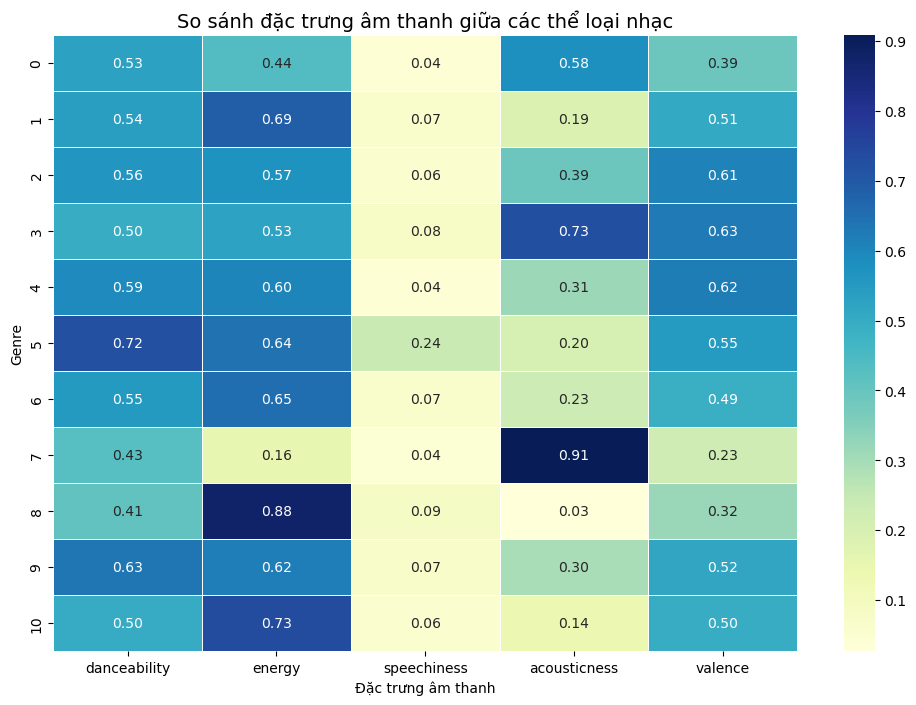

In [6]:
# ================================
# SO SÁNH NHIỀU FEATURE GIỮA CÁC GENRE
# ================================

# Chọn các feature cần phân tích
features = [
    'danceability',
    'energy',
    'speechiness',
    'acousticness',
    'valence'
]

# Tính giá trị trung bình theo genre
genre_features = df.groupby('Class')[features].mean()

# Hiển thị bảng
print(genre_features)

# ================================
# VẼ HEATMAP
# ================================

plt.figure(figsize=(12, 8))

sns.heatmap(
    genre_features,
    annot=True,      # hiện giá trị
    cmap='YlGnBu',   # màu sắc
    fmt='.2f',
    linewidths=0.5
)

# Tiêu đề
plt.title("So sánh đặc trưng âm thanh giữa các thể loại nhạc", fontsize=14)

# Nhãn trục
plt.xlabel("Đặc trưng âm thanh")
plt.ylabel("Genre")

# Hiển thị
plt.show()

# Chọn các feature này vì chúng phản ánh rõ đặc trưng âm thanh
# và có khả năng phân biệt các thể loại nhạc tốt nhất.

features = [
    'danceability',   # độ phù hợp để nhảy
    'energy',         # mức độ sôi động/mạnh
    'speechiness',    # mức độ giống lời nói (rap)
    'acousticness',   # mức độ acoustic/mộc
    'valence'         # mức độ vui vẻ/tích cực
]

# Đây là các feature tạo insight rõ giữa các genre:
#
# - HipHop:
#   speechiness và danceability thường cao
#
# - Metal:
#   energy cao, valence thấp
#
# - Acoustic/Folk:
#   acousticness cao, energy thấp
#
# - Pop:
#   danceability và valence cao
#
# Không chọn một số feature khác vì:
#
# - artist_name, track_name:
#   là dữ liệu text, không phù hợp để so sánh trung bình.
#
# - key, mode, time_signature:
#   là dữ liệu categorical/discrete,
#   khó phản ánh đặc trưng âm thanh tổng quát của genre.
#
# - loudness:
#   có liên hệ mạnh với energy nên dễ bị trùng ý nghĩa.
#
# - tempo:
#   có ảnh hưởng nhưng không phân biệt genre mạnh bằng các feature trên.
#
# - liveness:
#   thường không khác biệt rõ giữa các genre.
#
# - popularity:
#   phản ánh độ nổi tiếng hơn là đặc trưng âm thanh.
#
# - instrumentalness:
#   hữu ích cho Instrumental nhưng đa số genre còn lại thường thấp,
#   nên ít tạo sự khác biệt tổng quát hơn các feature được chọn.

# Mục đích:
#
# So sánh nhiều đặc trưng âm thanh giữa các thể loại nhạc
# để tìm ra “đặc trưng riêng” của từng genre.

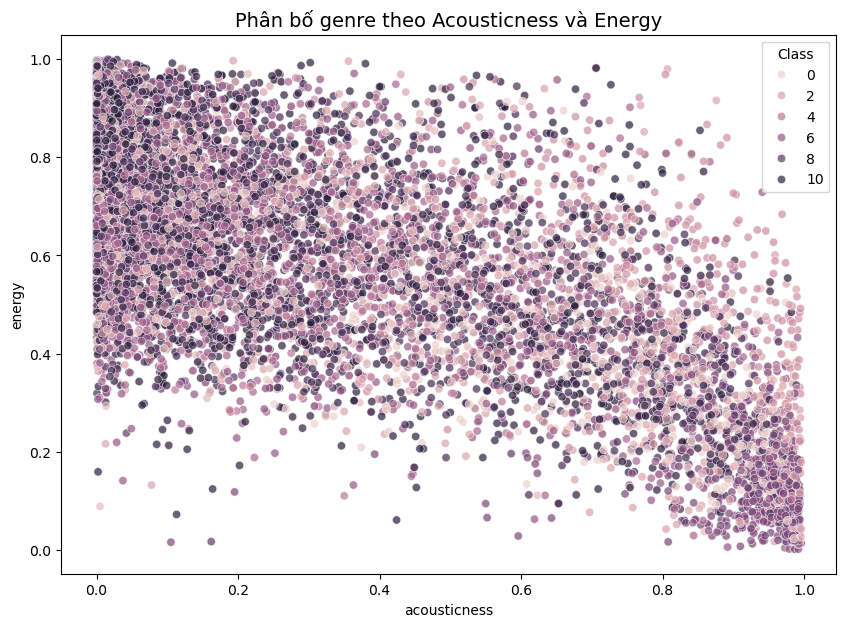

In [3]:
# ================================
# SCATTER PLOT:
# XEM GENRE NÀO TÁCH BIỆT / OVERLAP
# ================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='acousticness',
    y='energy',
    hue='Class',
    alpha=0.7
)

# Tiêu đề
plt.title("Phân bố genre theo Acousticness và Energy", fontsize=14)

# Hiển thị
plt.show()

In [ ]:
# Chọn acousticness và energy vì đây là hai feature
# có khả năng phân biệt các genre rất rõ ràng.
#
# - energy:
#   phản ánh mức độ mạnh, sôi động của bài hát.
#
# - acousticness:
#   phản ánh mức độ mộc/acoustic của bài hát.
#
# Hai feature này có tính chất gần như đối lập:
#
# - Metal/Rock:
#   thường energy cao và acousticness thấp.
#
# - Acoustic/Folk:
#   thường acousticness cao và energy thấp.
#
# Vì vậy khi vẽ scatter plot,
# các genre sẽ dễ tách thành các vùng khác nhau,
# giúp quan sát:
#
# - genre nào tách biệt tốt
# - genre nào bị overlap
#
# Ngoài ra, ở correlation matrix trước đó,
# energy và acousticness cũng có tương quan âm mạnh,
# cho thấy chúng mang nhiều thông tin quan trọng
# về phong cách âm thanh của bài hát.

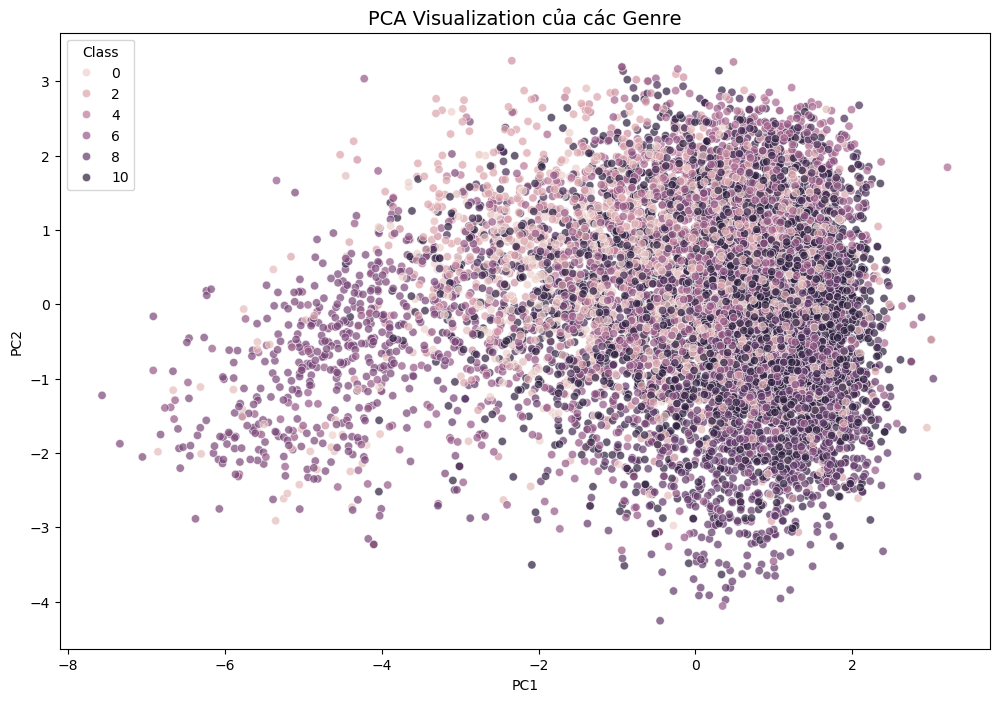

In [5]:
# ================================
# PCA VISUALIZATION
# ================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Chọn feature
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'valence',
    'tempo'
]

# Tạo dataframe mới chỉ gồm feature + Class
pca_data = df[features + ['Class']]

# Xóa missing values
pca_data = pca_data.dropna()

# Tách X và y
X = pca_data[features]

# Chuẩn hóa dữ liệu
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# Tạo dataframe PCA
pca_df = pd.DataFrame(
    data=X_pca,
    columns=['PC1', 'PC2']
)

# Thêm genre
pca_df['Class'] = pca_data['Class'].values

# ================================
# VẼ BIỂU ĐỒ
# ================================

plt.figure(figsize=(12,8))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Class',
    alpha=0.7
)

plt.title("PCA Visualization của các Genre", fontsize=14)

plt.show()

In [6]:
# Cấu trúc lưu ảnh hoặc file csv hoặc dữ liệu nào cần thiết
# Đây là cấu trúc lưu file csv, nhưng hầu như công đoạn này lưu ảnh
# --> dùng AI để sửa lại cho đúng ảnh mún lưu

now = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"{now}_data_multivariateAnalysis.csv"
filepath = os.path.join("..", "Notebooks", "EDA", "MultivariateAnalysis", filename)
os.makedirs(os.path.dirname(filepath), exist_ok=True)

df.to_csv(filepath, index=False)

print("Saved:", filepath)

Saved: ..\Notebooks\EDA\MultivariateAnalysis\20260510_232826_data_multivariateAnalysis.csv
